# Notebook 2 — Text Preprocessing
**Project:** Job Offer Scam Detection  
**Student:** Mohamed Baounna — SIIA S6  

---

## Objectives
1. Combine relevant text columns into a single representation
2. Apply each preprocessing step and justify its role
3. Save the processed dataset for use in later notebooks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

from preprocessing import (
    combine_text_columns, clean_text, tokenize,
    remove_stopwords, lemmatize, full_preprocess, preprocess_dataframe
)

sns.set_theme(style='whitegrid')
print('Ready.')

Ready.


## 1. Load Raw Data

In [2]:
df = pd.read_csv('../data/raw/fake_job_postings.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df[['title', 'description', 'fraudulent']].head(3)

Loaded: 17,880 rows × 18 columns


,title,description,fraudulent
0,Marketing Intern,"Food52, a fast-growing, James Beard Award-winn...",0
1,Customer Service - Cloud Video Production,Organised - Focused - Vibrant - Awesome!Do you...,0
2,Commissioning Machinery Assistant (CMA),"Our client, located in Houston, is actively se...",0


## 2. Step-by-Step Preprocessing

Each step is demonstrated and justified.

### Step 1 — Combine Text Columns
**Why:** A job posting's fraud signal is distributed across multiple fields (title, description, requirements, etc.).
Merging them into a single string maximises the information available to the classifier.

In [3]:
sample_idx = df.index[0]
df_combined = combine_text_columns(df)

print('=== BEFORE (description only) ===')
print(str(df.loc[sample_idx, 'description'])[:300])
print('\n=== AFTER (combined) ===')
print(df_combined.loc[sample_idx, 'combined_text'][:400])

=== BEFORE (description only) ===
Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curated recipe hub, is currently interviewing full- and part-time unpaid interns to work in a small team of editors, executives, and developers in its New York City headquarters.Reproducing and/or repackagi

=== AFTER (combined) ===
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly


### Step 2 — Lowercasing
**Why:** Normalises vocabulary. *Engineer* and *engineer* should be the same token.

In [4]:
sample = df_combined.loc[sample_idx, 'combined_text'][:200]
print('Before:', sample[:80])
print('After: ', sample.lower()[:80])

Before: Marketing Intern We're Food52, and we've created a groundbreaking and award-winn
After:  marketing intern we're food52, and we've created a groundbreaking and award-winn


### Step 3 — Remove Punctuation & Special Characters
**Why:** Punctuation carries little semantic value for bag-of-words models and adds noise.

In [5]:
raw   = 'Earn $5,000/week! Work from home — No experience needed. Apply NOW!!!'
clean = clean_text(raw)
print('Raw  :', raw)
print('Clean:', clean)

Raw  : Earn $5,000/week! Work from home — No experience needed. Apply NOW!!!
Clean: earn week work from home no experience needed apply now


### Step 4 — Tokenization
**Why:** Splits text into discrete units (tokens) that can be individually analysed or counted.

In [6]:
tokens = tokenize(clean)
print(f'Tokens ({len(tokens)}):', tokens)

Tokens (10): ['earn', 'week', 'work', 'from', 'home', 'no', 'experience', 'needed', 'apply', 'now']


### Step 5 — Stop Word Removal
**Why:** Common words (*the*, *is*, *and*) appear in all documents equally and do not help distinguish classes.

In [7]:
no_stop = remove_stopwords(tokens)
removed = set(tokens) - set(no_stop)
print(f'Removed stop words ({len(removed)}):', removed)
print(f'Remaining tokens   ({len(no_stop)}):', no_stop)

Removed stop words (3): {'no', 'from', 'now'}
Remaining tokens   (7): ['earn', 'week', 'work', 'home', 'experience', 'needed', 'apply']


### Step 6 — Lemmatization
**Why:** Reduces inflected forms to their base lemma (*running* → *run*, *applications* → *application*), shrinking vocabulary size and improving generalisation.

In [8]:
lemmas = lemmatize(no_stop)
print('Before lemmatization:', no_stop)
print('After  lemmatization:', lemmas)

Before lemmatization: ['earn', 'week', 'work', 'home', 'experience', 'needed', 'apply']
After  lemmatization: ['earn', 'week', 'work', 'home', 'experience', 'needed', 'apply']


## 3. Full Pipeline Applied to Dataset

In [9]:
print('Applying full preprocessing pipeline...')
df_processed = preprocess_dataframe(df)
print(f'Done. Processed {len(df_processed):,} documents.')
df_processed[['combined_text', 'processed_text', 'fraudulent']].head(3)

Applying full preprocessing pipeline...


Done. Processed 17,880 documents.


,combined_text,processed_text,fraudulent
0,"Marketing Intern We're Food52, and we've creat...",marketing intern food weve created groundbreak...,0
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...,0
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...,0


In [10]:
# Show before / after for a fraud example
fraud_example = df_processed[df_processed['fraudulent'] == 1].iloc[0]
print('=== ORIGINAL ===')
print(fraud_example['combined_text'][:400])
print('\n=== PREPROCESSED ===')
print(fraud_example['processed_text'][:400])

=== ORIGINAL ===
IC&E Technician                                                                                  Staffing &amp; Recruiting done right for the Oil &amp; Energy Industry!Represented candidates are automatically granted the following perks: Expert negotiations on your behalf, maximizing your compensation package and implimenting ongoing increases Significant signing bonus by Refined Resources (in add

=== PREPROCESSED ===
ice technician staffing amp recruiting done right oil amp energy industryrepresented candidate automatically granted following perk expert negotiation behalf maximizing compensation package implimenting ongoing increase significant signing bonus refined resource addition potential signing bonus client company offer year access anyperk significant corporate discount cell phone event ticket house cl


## 4. Vocabulary Statistics

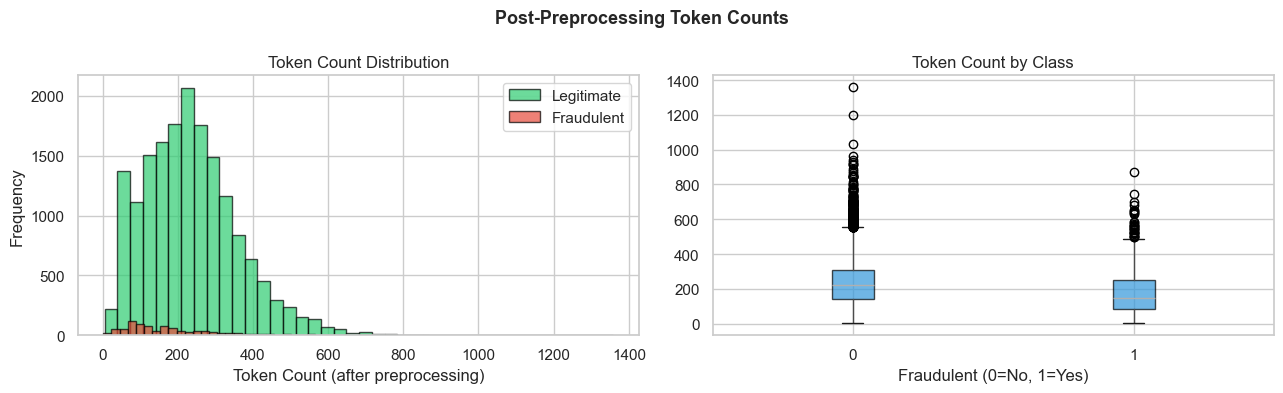


Mean token count by class:
              count        mean         std  min    25%    50%    75%     max
fraudulent                                                                   
0           17014.0  234.847126  126.304368  6.0  142.0  223.0  307.0  1359.0
1             866.0  181.323326  131.562243  2.0   87.0  148.0  249.0   869.0


In [11]:
df_processed['token_count']    = df_processed['processed_text'].apply(lambda x: len(x.split()))
df_processed['raw_char_count'] = df_processed['combined_text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Fraudulent')]:
    subset = df_processed[df_processed['fraudulent'] == label]['token_count']
    axes[0].hist(subset, bins=40, alpha=0.7, color=color, label=name, edgecolor='black')

axes[0].set_xlabel('Token Count (after preprocessing)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Token Count Distribution')
axes[0].legend()

df_processed.boxplot(column='token_count', by='fraudulent', ax=axes[1],
                     patch_artist=True,
                     boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title('Token Count by Class')
axes[1].set_xlabel('Fraudulent (0=No, 1=Yes)')
plt.suptitle('Post-Preprocessing Token Counts', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/token_distribution.png', bbox_inches='tight')
plt.show()

print('\nMean token count by class:')
print(df_processed.groupby('fraudulent')['token_count'].describe())

## 5. Save Processed Dataset

In [12]:
os.makedirs('../data/processed', exist_ok=True)
out_path = '../data/processed/processed_data.csv'
df_processed[['processed_text', 'fraudulent']].to_csv(out_path, index=False)
print(f'Saved to {out_path}  ({len(df_processed):,} rows)')

Saved to ../data/processed/processed_data.csv  (17,880 rows)


## 6. Summary

| Step | Tool | Justification |
|------|------|---------------|
| Column combination | pandas | Maximises information per document |
| Lowercase | str.lower() | Vocabulary normalisation |
| Remove special chars | regex | Reduces noise |
| Tokenization | NLTK word_tokenize | Splits text into analysable units |
| Stop word removal | NLTK stopwords | Removes uninformative common words |
| Lemmatization | NLTK WordNetLemmatizer | Reduces vocabulary, improves generalisation |

> **Next:** Notebook 3 — Text Representation (TF-IDF vs Word2Vec)